In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [92]:
df = pd.read_csv(r"C:\Users\rahul\OneDrive\Desktop\Q_Skill_Internship\bengaluru_house_prices.csv")
print(df.head())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  


In [93]:
print(df.info())

print("description of the dataset:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None
description of the dataset:
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000

In [94]:
print("Number of Rows:")
print(len(df))

Number of Rows:
13320


In [95]:
print("Number of null values in each column:")
print(df.isnull().sum())

Number of null values in each column:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [96]:
df['society'] = df['society'].fillna(df['society'].mode()[0])

df['balcony'] = df['balcony'].fillna(df['balcony'].mode()[0])

df['bath'] = df['bath'].fillna(df['bath'].mode()[0])

df['size'] = df['size'].fillna(df['size'].mode()[0])

df['location'] = df['location'].fillna(df['location'].mode()[0])


In [97]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

df = df[
    (df['price'] >= Q1 - 1.5*IQR) &
    (df['price'] <= Q3 + 1.5*IQR)
]

In [98]:
print("after filling null values")

print(df.info())

print("Number of null values in each column:")
print(df.isnull().sum())


after filling null values
<class 'pandas.core.frame.DataFrame'>
Index: 12044 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12044 non-null  object 
 1   availability  12044 non-null  object 
 2   location      12044 non-null  object 
 3   size          12044 non-null  object 
 4   society       12044 non-null  object 
 5   total_sqft    12044 non-null  object 
 6   bath          12044 non-null  float64
 7   balcony       12044 non-null  float64
 8   price         12044 non-null  float64
dtypes: float64(3), object(6)
memory usage: 940.9+ KB
None
Number of null values in each column:
area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64


In [99]:

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

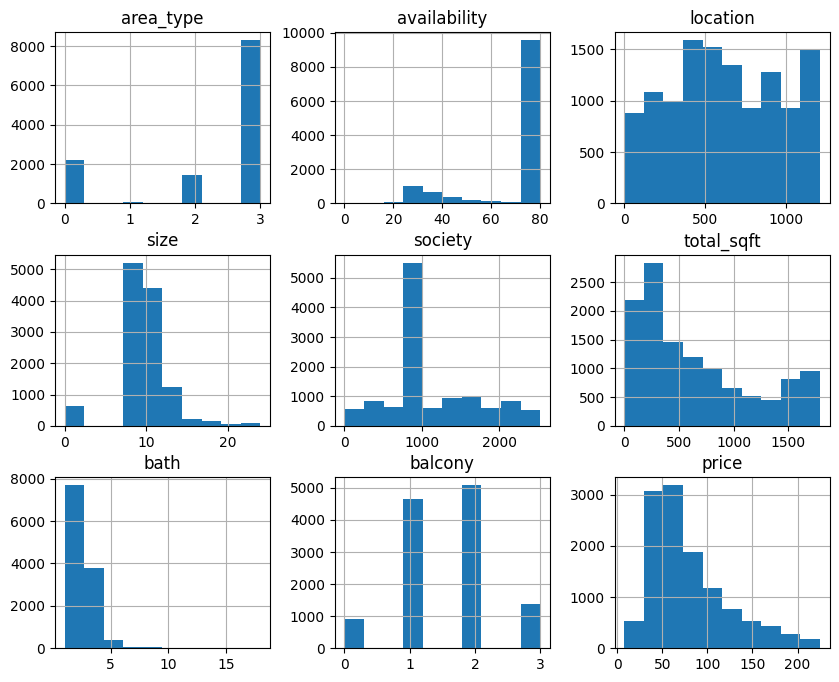

In [100]:
df.hist(figsize=(10,8))
plt.show()

In [101]:
x = df[['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony']]

y =df['price']




In [102]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [103]:
model=  XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [104]:
y_pred = model.predict(x_test)

In [105]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 492.02938116819666
R2 Score: 0.7194133822415743


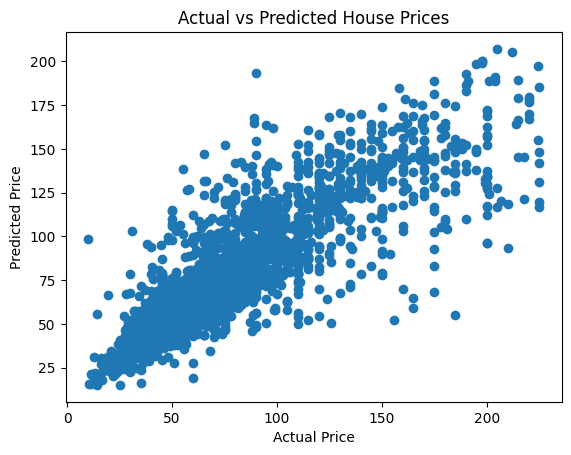

In [106]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()